
# Human Variables and Reservoir Storage — Aligned Final Pipeline

This notebook:

1. Downloads RISE storage and total-release data.
2. Downloads upstream USGS streamflow.
3. Converts May–June release and inflow to acre-feet.
4. Prints the date and year coverage for every source.
5. Aligns the datasets by reservoir and year.
6. Uses the requested 1980–2014 training and 2015–2025 testing split when possible.
7. Automatically uses a chronological fallback split when a reservoir lacks post-2015 records.
8. Runs OLS and reports R², RMSE, MAE, coefficients, VIF, and plots.

## Model

\[
\Delta Storage =
eta_0 +
eta_1(Total\ Release) +
eta_2(Natural\ Inflow) +
\epsilon
\]

- **Human X:** `release_total_af`
- **Natural control X:** `may_june_inflow_af`
- **Y:** `delta_storage_af`


In [1]:

!pip -q install pandas numpy requests statsmodels scikit-learn matplotlib

import warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)


## 1. Fixed project settings

In [2]:

START_YEAR = 1980
END_YEAR = 2025
MONTHS = [5, 6]

REQUESTED_TRAIN_END = 2014
REQUESTED_TEST_START = 2015

RESERVOIRS = {
    "Blue Mesa Reservoir": {
        "storage_id": 76,
        "release_id": 4349,       # acre-feet per day
        "usgs_gauge": "09114500",
    },
    "Navajo Reservoir": {
        "storage_id": 613,
        "release_id": 4355,       # acre-feet per day
        "usgs_gauge": "09346400",
    },
    "Pueblo Reservoir": {
        "storage_id": 681,
        "release_id": 684,        # CFS
        "usgs_gauge": "07097000",
    },
}

CFS_DAY_TO_AF = 1.983471074


## 2. RISE downloader and metadata parser

In [3]:

RISE_DOWNLOAD = "https://data.usbr.gov/rise/api/result/download"

def download_rise_series(item_id, start_year=START_YEAR, end_year=END_YEAR):
    params = {
        "itemId": int(item_id),
        "after": f"{start_year}-01-01",
        "before": f"{end_year}-12-31",
    }

    response = requests.get(RISE_DOWNLOAD, params=params, timeout=120)
    response.raise_for_status()
    payload = response.json()

    rows = [
        value for key, value in payload.items()
        if str(key).isdigit() and isinstance(value, dict)
    ]

    if not rows:
        raise ValueError(f"No observations returned for RISE item {item_id}.")

    raw = pd.DataFrame(rows)

    if "dateTime" not in raw.columns or "result" not in raw.columns:
        raise ValueError(
            f"RISE item {item_id} did not contain dateTime/result fields. "
            f"Columns: {list(raw.columns)}"
        )

    series = pd.DataFrame({
        "date": pd.to_datetime(raw["dateTime"], errors="coerce"),
        "value": pd.to_numeric(raw["result"], errors="coerce"),
    }).dropna(subset=["date", "value"])

    series = (
        series.sort_values("date")
              .drop_duplicates("date")
              .reset_index(drop=True)
    )

    metadata = {
        "item_id": item_id,
        "location": payload.get("Location", {}).get("Name"),
        "parameter": payload.get("Parameter Name:"),
        "units": payload.get("Units"),
        "timestep": payload.get("Timestep"),
        "aggregation": payload.get("Aggregation"),
        "start_date": series["date"].min(),
        "end_date": series["date"].max(),
        "observations": len(series),
    }

    return series, metadata


## 3. Download and aggregate storage

In [4]:

def may_june_storage_change(series):
    seasonal = series[series["date"].dt.month.isin(MONTHS)].copy()
    seasonal["year"] = seasonal["date"].dt.year

    rows = []
    for year, group in seasonal.groupby("year"):
        group = group.sort_values("date")
        if len(group) >= 2:
            rows.append({
                "water_year": int(year),
                "storage_start_af": float(group.iloc[0]["value"]),
                "storage_end_af": float(group.iloc[-1]["value"]),
                "delta_storage_af": float(
                    group.iloc[-1]["value"] - group.iloc[0]["value"]
                ),
                "storage_days": int(len(group)),
            })

    return pd.DataFrame(rows)

storage_frames = []
coverage_rows = []

for reservoir, config in RESERVOIRS.items():
    series, metadata = download_rise_series(config["storage_id"])
    annual = may_june_storage_change(series)
    annual.insert(0, "reservoir", reservoir)
    storage_frames.append(annual)

    coverage_rows.append({
        "reservoir": reservoir,
        "source": "RISE storage",
        **metadata,
        "first_annual_year": annual["water_year"].min(),
        "last_annual_year": annual["water_year"].max(),
        "annual_rows": len(annual),
    })

storage_df = pd.concat(storage_frames, ignore_index=True)
display(storage_df.head())


,reservoir,water_year,storage_start_af,storage_end_af,delta_storage_af,storage_days
0,Blue Mesa Reservoir,1980,357660.0,782043.0,424383.0,61
1,Blue Mesa Reservoir,1981,390624.0,427404.0,36780.0,61
2,Blue Mesa Reservoir,1982,243657.0,652575.0,408918.0,61
3,Blue Mesa Reservoir,1983,436808.0,819539.0,382731.0,61
4,Blue Mesa Reservoir,1984,220806.0,809810.0,589004.0,61


## 4. Download and aggregate human-controlled releases

In [5]:

def may_june_release_total_af(series, units):
    seasonal = series[series["date"].dt.month.isin(MONTHS)].copy()
    seasonal["water_year"] = seasonal["date"].dt.year

    unit_text = str(units).lower().strip()

    if "cfs" in unit_text or "ft3/s" in unit_text:
        annual = (
            seasonal.groupby("water_year", as_index=False)["value"]
                    .agg(["sum", "count"])
                    .reset_index()
                    .rename(columns={"count": "release_days"})
        )
        annual["release_total_af"] = annual["sum"] * CFS_DAY_TO_AF
        return annual[["water_year", "release_total_af", "release_days"]]

    if "af" in unit_text or "acre" in unit_text:
        annual = (
            seasonal.groupby("water_year", as_index=False)["value"]
                    .agg(["sum", "count"])
                    .reset_index()
                    .rename(columns={
                        "sum": "release_total_af",
                        "count": "release_days"
                    })
        )
        return annual[["water_year", "release_total_af", "release_days"]]

    raise ValueError(f"Unsupported release units: {units}")

release_frames = []

for reservoir, config in RESERVOIRS.items():
    series, metadata = download_rise_series(config["release_id"])
    annual = may_june_release_total_af(series, metadata["units"])
    annual.insert(0, "reservoir", reservoir)
    release_frames.append(annual)

    coverage_rows.append({
        "reservoir": reservoir,
        "source": "RISE total release",
        **metadata,
        "first_annual_year": annual["water_year"].min(),
        "last_annual_year": annual["water_year"].max(),
        "annual_rows": len(annual),
    })

release_df = pd.concat(release_frames, ignore_index=True)
display(release_df.head())


,reservoir,water_year,release_total_af,release_days
0,Blue Mesa Reservoir,1980,237636.5600,61
1,Blue Mesa Reservoir,1981,121340.8190,61
2,Blue Mesa Reservoir,1982,53077.6680,61
3,Blue Mesa Reservoir,1983,176410.0885,61
4,Blue Mesa Reservoir,1984,431801.6710,61


## 5. Download and aggregate natural upstream inflow

In [6]:

USGS_DV = "https://waterservices.usgs.gov/nwis/dv/"

def download_usgs_daily_cfs(site):
    params = {
        "format": "json",
        "sites": site,
        "startDT": f"{START_YEAR}-01-01",
        "endDT": f"{END_YEAR}-12-31",
        "parameterCd": "00060",
        "siteStatus": "all",
    }

    response = requests.get(USGS_DV, params=params, timeout=120)
    response.raise_for_status()
    payload = response.json()

    rows = []
    for time_series in payload.get("value", {}).get("timeSeries", []):
        for value_block in time_series.get("values", []):
            for observation in value_block.get("value", []):
                rows.append({
                    "date": observation.get("dateTime"),
                    "cfs": observation.get("value"),
                })

    data = pd.DataFrame(rows)

    if data.empty:
        raise ValueError(f"No USGS data returned for gauge {site}.")

    data["date"] = (
        pd.to_datetime(data["date"], errors="coerce", utc=True)
          .dt.tz_convert(None)
    )
    data["cfs"] = pd.to_numeric(data["cfs"], errors="coerce")

    return (
        data.dropna(subset=["date", "cfs"])
            .sort_values("date")
            .drop_duplicates("date")
    )

def may_june_inflow_total_af(series):
    seasonal = series[series["date"].dt.month.isin(MONTHS)].copy()
    seasonal["water_year"] = seasonal["date"].dt.year

    annual = (
        seasonal.groupby("water_year", as_index=False)["cfs"]
                .agg(["sum", "mean", "count"])
                .reset_index()
                .rename(columns={
                    "mean": "may_june_mean_cfs",
                    "count": "inflow_days"
                })
    )

    annual["may_june_inflow_af"] = annual["sum"] * CFS_DAY_TO_AF

    return annual[
        ["water_year", "may_june_inflow_af", "may_june_mean_cfs", "inflow_days"]
    ]

inflow_frames = []

for reservoir, config in RESERVOIRS.items():
    series = download_usgs_daily_cfs(config["usgs_gauge"])
    annual = may_june_inflow_total_af(series)
    annual.insert(0, "reservoir", reservoir)
    inflow_frames.append(annual)

    coverage_rows.append({
        "reservoir": reservoir,
        "source": f"USGS inflow {config['usgs_gauge']}",
        "item_id": config["usgs_gauge"],
        "location": reservoir,
        "parameter": "Discharge",
        "units": "CFS",
        "timestep": "daily",
        "aggregation": "daily mean",
        "start_date": series["date"].min(),
        "end_date": series["date"].max(),
        "observations": len(series),
        "first_annual_year": annual["water_year"].min(),
        "last_annual_year": annual["water_year"].max(),
        "annual_rows": len(annual),
    })

inflow_df = pd.concat(inflow_frames, ignore_index=True)
display(inflow_df.head())


,reservoir,water_year,may_june_inflow_af,may_june_mean_cfs,inflow_days
0,Blue Mesa Reservoir,1980,332429.752002,2747.540984,61
1,Blue Mesa Reservoir,1981,82421.157009,681.213115,61
2,Blue Mesa Reservoir,1982,232665.123922,1922.983607,61
3,Blue Mesa Reservoir,1983,251944.462762,2082.327869,61
4,Blue Mesa Reservoir,1984,457882.313962,3784.409836,61


## 6. Diagnose coverage and align years

In [7]:

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df[[
    "reservoir", "source", "item_id", "units",
    "start_date", "end_date",
    "first_annual_year", "last_annual_year", "annual_rows"
]])

model_df = (
    storage_df
    .merge(
        release_df,
        on=["reservoir", "water_year"],
        how="outer",
        indicator="storage_release_match"
    )
    .merge(
        inflow_df,
        on=["reservoir", "water_year"],
        how="outer",
        indicator="inflow_match"
    )
    .sort_values(["reservoir", "water_year"])
)

required = [
    "delta_storage_af",
    "release_total_af",
    "may_june_inflow_af"
]

model_df["complete_case"] = model_df[required].notna().all(axis=1)

print("Merged-row coverage:")
display(
    model_df.groupby("reservoir").agg(
        first_merged_year=("water_year", "min"),
        last_merged_year=("water_year", "max"),
        merged_rows=("water_year", "count"),
        complete_rows=("complete_case", "sum"),
    )
)

print("Complete years by reservoir:")
for reservoir, group in model_df.groupby("reservoir"):
    years = group.loc[group["complete_case"], "water_year"].tolist()
    print(reservoir, years)

complete_df = model_df[model_df["complete_case"]].copy()
complete_df.to_csv(
    "reservoir_human_variables_aligned_model_data.csv",
    index=False
)

print("Saved reservoir_human_variables_aligned_model_data.csv")


,reservoir,source,item_id,units,start_date,end_date,first_annual_year,last_annual_year,annual_rows
0,Blue Mesa Reservoir,RISE storage,76,af,1980-01-01 07:00:00,2025-12-31 07:00:00,1980,2025,46
1,Navajo Reservoir,RISE storage,613,af,1980-01-01 07:00:00,2025-12-31 07:00:00,1980,2025,46
2,Pueblo Reservoir,RISE storage,681,af,1980-01-01 06:00:00,2025-12-31 07:00:00,1980,2025,46
3,Blue Mesa Reservoir,RISE total release,4349,af,1980-01-01 07:00:00,2025-12-31 07:00:00,1980,2025,46
4,Navajo Reservoir,RISE total release,4355,af,1980-09-01 07:00:00,2025-12-31 07:00:00,1981,2025,45
5,Pueblo Reservoir,RISE total release,684,cfs,1984-10-01 06:00:00,2025-12-31 07:00:00,1985,2025,37
6,Blue Mesa Reservoir,USGS inflow 09114500,09114500,CFS,1980-01-01 00:00:00,2025-12-31 00:00:00,1980,2025,46
7,Navajo Reservoir,USGS inflow 09346400,09346400,CFS,1980-01-01 00:00:00,2025-12-31 00:00:00,1980,2025,46
8,Pueblo Reservoir,USGS inflow 07097000,07097000,CFS,1980-01-01 00:00:00,2007-09-29 00:00:00,1980,2007,28


Merged-row coverage:


,first_merged_year,last_merged_year,merged_rows,complete_rows
reservoir,,,,
Blue Mesa Reservoir,1980,2025,46,46
Navajo Reservoir,1980,2025,46,45
Pueblo Reservoir,1980,2025,46,23


Complete years by reservoir:
Blue Mesa Reservoir [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Navajo Reservoir [1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Pueblo Reservoir [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]
Saved reservoir_human_variables_aligned_model_data.csv


## 7. Choose chronological train/test periods automatically

In [8]:

def choose_split(data):
    years = sorted(data["water_year"].unique())

    requested_train = data[
        data["water_year"] <= REQUESTED_TRAIN_END
    ]
    requested_test = data[
        data["water_year"] >= REQUESTED_TEST_START
    ]

    if len(requested_train) >= 8 and len(requested_test) >= 2:
        return {
            "method": "Requested 1980-2014 / 2015-2025",
            "train": requested_train,
            "test": requested_test,
        }

    # Fallback: use the final 25% of chronologically ordered observations
    # as testing, with at least 2 test rows.
    n = len(data)
    test_n = max(2, int(np.ceil(n * 0.25)))
    split_index = n - test_n

    if split_index < 5:
        return None

    return {
        "method": "Chronological 75/25 fallback",
        "train": data.iloc[:split_index],
        "test": data.iloc[split_index:],
    }

split_rows = []

for reservoir, group in complete_df.groupby("reservoir"):
    ordered = group.sort_values("water_year").reset_index(drop=True)
    split = choose_split(ordered)

    if split is None:
        split_rows.append({
            "reservoir": reservoir,
            "method": "Insufficient data",
            "train_start": np.nan,
            "train_end": np.nan,
            "n_train": 0,
            "test_start": np.nan,
            "test_end": np.nan,
            "n_test": 0,
        })
        continue

    train = split["train"]
    test = split["test"]

    split_rows.append({
        "reservoir": reservoir,
        "method": split["method"],
        "train_start": train["water_year"].min(),
        "train_end": train["water_year"].max(),
        "n_train": len(train),
        "test_start": test["water_year"].min(),
        "test_end": test["water_year"].max(),
        "n_test": len(test),
    })

split_df = pd.DataFrame(split_rows)
display(split_df)


,reservoir,method,train_start,train_end,n_train,test_start,test_end,n_test
0,Blue Mesa Reservoir,Requested 1980-2014 / 2015-2025,1980,2014,35,2015,2025,11
1,Navajo Reservoir,Requested 1980-2014 / 2015-2025,1981,2014,34,2015,2025,11
2,Pueblo Reservoir,Chronological 75/25 fallback,1985,2001,17,2002,2007,6


## 8. Run OLS and diagnostics


Blue Mesa Reservoir
Requested 1980-2014 / 2015-2025
Train: 1980-2014 (n=35)
Test: 2015-2025 (n=11)
Test R² = 0.891 | RMSE = 40,564 AF | MAE = 36,003 AF


,coefficient,p_value,ci_low,ci_high
const,-12342.7644,0.4754,-47152.4585,22466.9297
release_total_af,-1.0209,0.0000,-1.2433,-0.7985
may_june_inflow_af,1.9883,0.0000,1.7655,2.2111


VIF:


,variable,VIF
0,release_total_af,2.647
1,may_june_inflow_af,2.647


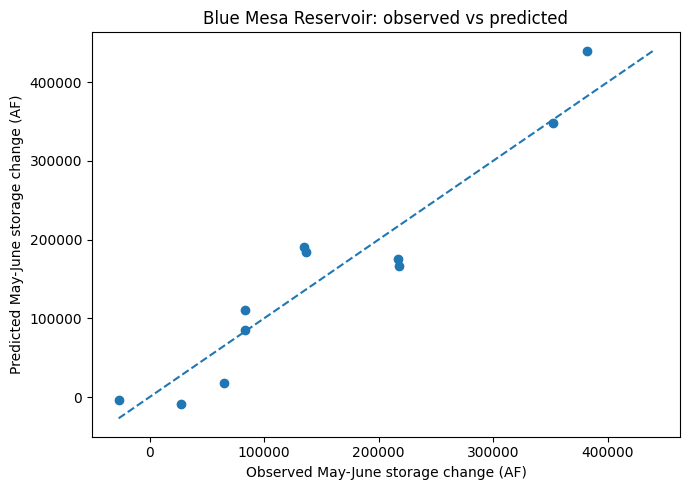

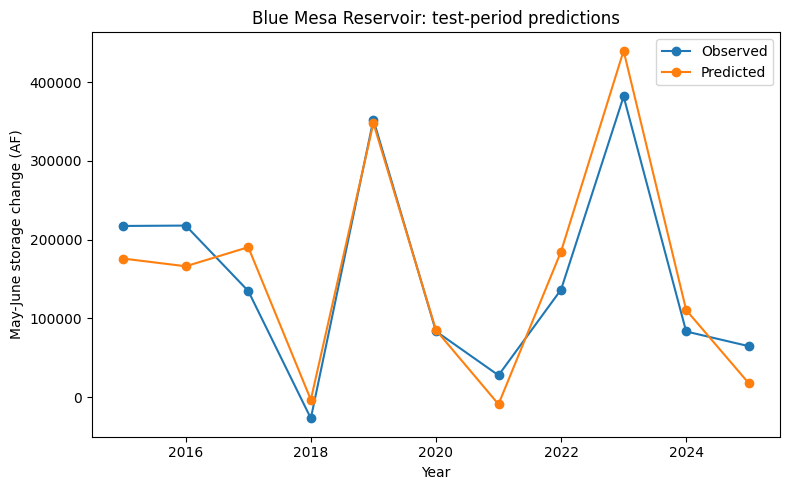


Navajo Reservoir
Requested 1980-2014 / 2015-2025
Train: 1981-2014 (n=34)
Test: 2015-2025 (n=11)
Test R² = 0.942 | RMSE = 37,047 AF | MAE = 29,759 AF


,coefficient,p_value,ci_low,ci_high
const,-77184.1114,0.0002,-114382.1235,-39986.0994
release_total_af,-0.8639,0.0000,-1.0100,-0.7179
may_june_inflow_af,1.8806,0.0000,1.6157,2.1455


VIF:


,variable,VIF
0,release_total_af,2.241
1,may_june_inflow_af,2.241


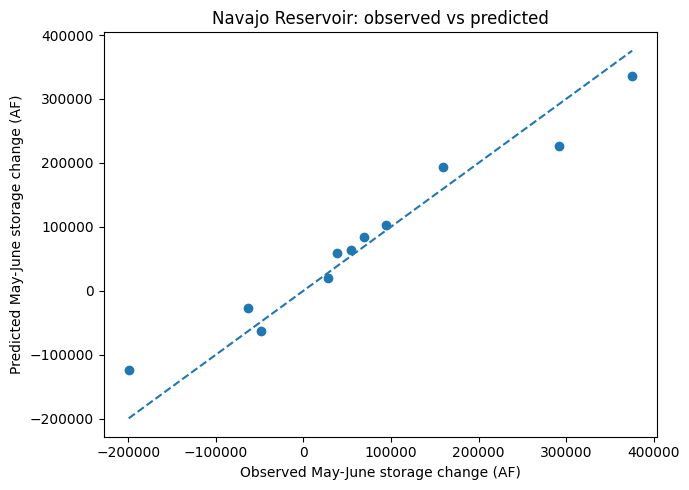

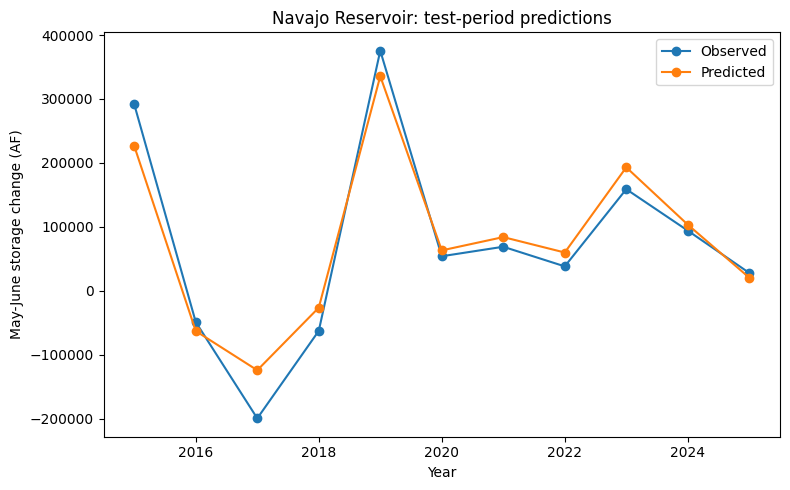


Pueblo Reservoir
Chronological 75/25 fallback
Train: 1985-2001 (n=17)
Test: 2002-2007 (n=6)
Test R² = 0.486 | RMSE = 10,160 AF | MAE = 8,865 AF


,coefficient,p_value,ci_low,ci_high
const,-49897.7397,0.0027,-79301.5318,-20493.9477
release_total_af,0.2376,0.1300,-0.0792,0.5543
may_june_inflow_af,-0.0655,0.6951,-0.4166,0.2856


VIF:


,variable,VIF
0,release_total_af,8.852
1,may_june_inflow_af,8.852


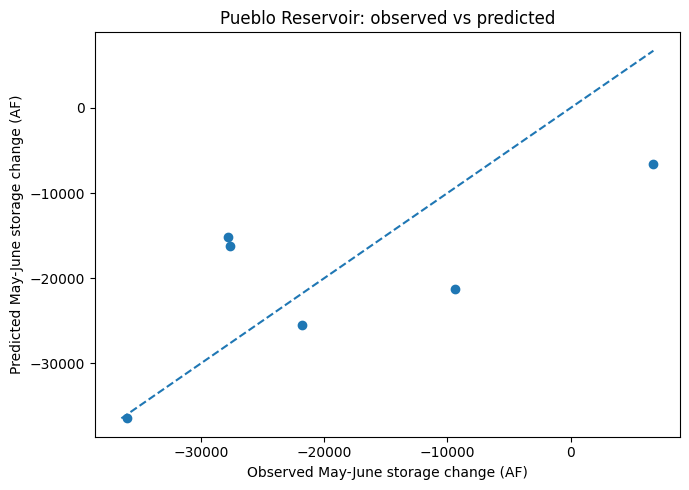

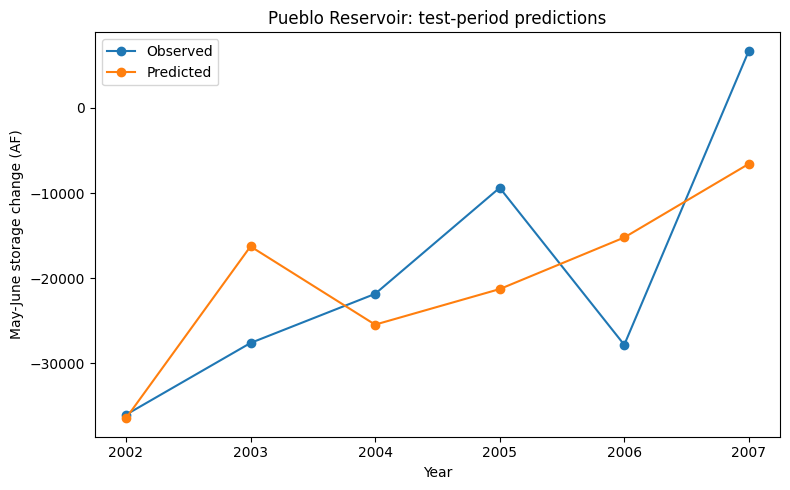

,reservoir,split_method,n_train,n_test,train_start,train_end,test_start,test_end,train_r2,test_r2,train_rmse_af,test_rmse_af,train_mae_af,test_mae_af
0,Blue Mesa Reservoir,Requested 1980-2014 / 2015-2025,35,11,1980,2014,2015,2025,0.925,0.891,39111.757,40564.220,30333.014,36003.089
1,Navajo Reservoir,Requested 1980-2014 / 2015-2025,34,11,1981,2014,2015,2025,0.873,0.942,42591.127,37046.895,31390.672,29758.652
2,Pueblo Reservoir,Chronological 75/25 fallback,17,6,1985,2001,2002,2007,0.493,0.486,16490.016,10160.370,14270.290,8864.879


Saved:
reservoir_human_variables_ols_summary.csv
reservoir_human_variables_ols_predictions.csv


In [9]:

TARGET = "delta_storage_af"
PREDICTORS = ["release_total_af", "may_june_inflow_af"]

def calculate_vif(X):
    if X.shape[1] == 1:
        return pd.DataFrame({
            "variable": X.columns,
            "VIF": [1.0]
        })

    X_constant = sm.add_constant(X, has_constant="add")

    rows = []
    for index, variable in enumerate(X_constant.columns):
        if variable == "const":
            continue

        rows.append({
            "variable": variable,
            "VIF": variance_inflation_factor(
                X_constant.values,
                index
            )
        })

    return pd.DataFrame(rows)

results = []
prediction_frames = []

for reservoir, group in complete_df.groupby("reservoir"):
    ordered = group.sort_values("water_year").reset_index(drop=True)
    split = choose_split(ordered)

    if split is None:
        print(f"Skipping {reservoir}: insufficient aligned observations.")
        continue

    train = split["train"].copy()
    test = split["test"].copy()

    X_train = sm.add_constant(
        train[PREDICTORS],
        has_constant="add"
    )
    X_test = sm.add_constant(
        test[PREDICTORS],
        has_constant="add"
    )

    y_train = train[TARGET]
    y_test = test[TARGET]

    model = sm.OLS(y_train, X_train).fit()

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    result = {
        "reservoir": reservoir,
        "split_method": split["method"],
        "n_train": len(train),
        "n_test": len(test),
        "train_start": train["water_year"].min(),
        "train_end": train["water_year"].max(),
        "test_start": test["water_year"].min(),
        "test_end": test["water_year"].max(),
        "train_r2": r2_score(y_train, train_prediction),
        "test_r2": r2_score(y_test, test_prediction),
        "train_rmse_af": np.sqrt(
            mean_squared_error(y_train, train_prediction)
        ),
        "test_rmse_af": np.sqrt(
            mean_squared_error(y_test, test_prediction)
        ),
        "train_mae_af": mean_absolute_error(
            y_train, train_prediction
        ),
        "test_mae_af": mean_absolute_error(
            y_test, test_prediction
        ),
    }

    results.append(result)

    predictions = test[
        ["reservoir", "water_year", TARGET]
    ].copy()

    predictions["predicted_delta_storage_af"] = test_prediction
    predictions["residual_af"] = (
        predictions[TARGET]
        - predictions["predicted_delta_storage_af"]
    )
    prediction_frames.append(predictions)

    print("\n" + "=" * 90)
    print(reservoir)
    print(split["method"])
    print(
        f"Train: {result['train_start']}-{result['train_end']} "
        f"(n={result['n_train']})"
    )
    print(
        f"Test: {result['test_start']}-{result['test_end']} "
        f"(n={result['n_test']})"
    )
    print(
        f"Test R² = {result['test_r2']:.3f} | "
        f"RMSE = {result['test_rmse_af']:,.0f} AF | "
        f"MAE = {result['test_mae_af']:,.0f} AF"
    )

    coefficient_table = pd.DataFrame({
        "coefficient": model.params,
        "p_value": model.pvalues,
        "ci_low": model.conf_int()[0],
        "ci_high": model.conf_int()[1],
    })
    display(coefficient_table.round(4))

    print("VIF:")
    display(calculate_vif(train[PREDICTORS]).round(3))

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, test_prediction)

    lower = min(y_test.min(), test_prediction.min())
    upper = max(y_test.max(), test_prediction.max())

    plt.plot([lower, upper], [lower, upper], linestyle="--")
    plt.xlabel("Observed May-June storage change (AF)")
    plt.ylabel("Predicted May-June storage change (AF)")
    plt.title(f"{reservoir}: observed vs predicted")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        test["water_year"],
        y_test,
        marker="o",
        label="Observed"
    )
    plt.plot(
        test["water_year"],
        test_prediction,
        marker="o",
        label="Predicted"
    )
    plt.xlabel("Year")
    plt.ylabel("May-June storage change (AF)")
    plt.title(f"{reservoir}: test-period predictions")
    plt.legend()
    plt.tight_layout()
    plt.show()

summary_df = pd.DataFrame(results)
prediction_df = (
    pd.concat(prediction_frames, ignore_index=True)
    if prediction_frames else pd.DataFrame()
)

display(summary_df.round(3))

summary_df.to_csv(
    "reservoir_human_variables_ols_summary.csv",
    index=False
)
prediction_df.to_csv(
    "reservoir_human_variables_ols_predictions.csv",
    index=False
)

print("Saved:")
print("reservoir_human_variables_ols_summary.csv")
print("reservoir_human_variables_ols_predictions.csv")



## Interpretation guide

The main human-action coefficient is `release_total_af`.

- A **negative release coefficient** means larger releases are associated with a more negative storage change after accounting for natural inflow.
- A **positive release coefficient** can occur in wet years when operators release more water while storage still rises.
- Test R² indicates how much test-period variation is captured.
- RMSE and MAE report prediction error in acre-feet.
- VIF checks whether release and inflow are too strongly related.

Use careful wording:

> Human-controlled releases are associated with reservoir storage changes after accounting for natural inflow.

OLS does not by itself prove that human actions caused all observed changes.
